In [1]:
!pip install stable-baselines3 gymnasium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 11.3 MB/s eta 0:00:00


In [2]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces

class GridWorldEnv(gym.Env):
    def __init__(self, grid_size=5, n_obstacles=3):
        super().__init__()
        self.grid_size = grid_size
        self.n_obstacles = n_obstacles
        self.action_space = spaces.Discrete(4)

        # 3 отдельных "слоя": позиция агента, позиция цели, препятствия
        # каждый слой — своя сетка из 0 и 1 (one-hot), без ложного порядка чисел
        self.observation_space = spaces.Box(
            low=0, high=1, shape=(3 * grid_size * grid_size,), dtype=np.float32
        )
        self.max_steps = 50

    def _get_obs(self):
        agent_layer = np.zeros((self.grid_size, self.grid_size), dtype=np.float32)
        goal_layer = np.zeros((self.grid_size, self.grid_size), dtype=np.float32)
        obstacle_layer = np.zeros((self.grid_size, self.grid_size), dtype=np.float32)

        agent_layer[self.agent_pos[1], self.agent_pos[0]] = 1
        goal_layer[self.goal_pos[1], self.goal_pos[0]] = 1
        for obs_pos in self.obstacles:
            obstacle_layer[obs_pos[1], obs_pos[0]] = 1

        return np.concatenate([
            agent_layer.flatten(), goal_layer.flatten(), obstacle_layer.flatten()
        ])

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.agent_pos = np.array([0, 0])
        self.goal_pos = np.array([self.grid_size - 1, self.grid_size - 1])

        self.obstacles = []
        while len(self.obstacles) < self.n_obstacles:
            pos = self.np_random.integers(0, self.grid_size, size=2)
            if not np.array_equal(pos, self.agent_pos) and not np.array_equal(pos, self.goal_pos):
                if not any(np.array_equal(pos, o) for o in self.obstacles):
                    self.obstacles.append(pos)

        self.steps = 0
        return self._get_obs(), {}

    def step(self, action):
        self.steps += 1
        old_pos = self.agent_pos.copy()
        new_pos = self.agent_pos.copy()

        if action == 0:
            new_pos[1] = min(self.grid_size - 1, new_pos[1] + 1)
        elif action == 1:
            new_pos[1] = max(0, new_pos[1] - 1)
        elif action == 2:
            new_pos[0] = max(0, new_pos[0] - 1)
        elif action == 3:
            new_pos[0] = min(self.grid_size - 1, new_pos[0] + 1)

        hit_obstacle = any(np.array_equal(new_pos, obs) for obs in self.obstacles)
        hit_wall = np.array_equal(new_pos, old_pos)  # упёрся в границу — позиция не изменилась

        if not hit_obstacle:
            self.agent_pos = new_pos

        reached_goal = np.array_equal(self.agent_pos, self.goal_pos)

        if reached_goal:
            reward = 10.0
        elif hit_obstacle:
            reward = -5.0
        elif hit_wall:
            reward = -1.0  # отдельный, заметный штраф именно за удар в границу поля
        else:
            old_dist = np.linalg.norm(old_pos - self.goal_pos)
            new_dist = np.linalg.norm(self.agent_pos - self.goal_pos)
            reward = -0.1 + 0.5 * (old_dist - new_dist)

        terminated = reached_goal
        truncated = self.steps >= self.max_steps
        return self._get_obs(), reward, terminated, truncated, {}

    def render(self):
        grid = np.full((self.grid_size, self.grid_size), '.')
        for obs_pos in self.obstacles:
            grid[obs_pos[1], obs_pos[0]] = 'X'
        grid[self.goal_pos[1], self.goal_pos[0]] = 'G'
        grid[self.agent_pos[1], self.agent_pos[0]] = 'A'
        print('\n'.join(' '.join(row) for row in grid[::-1]))
        print()

In [3]:
from stable_baselines3 import DQN
from stable_baselines3.common.env_checker import check_env

env = GridWorldEnv(grid_size=5, n_obstacles=3)
check_env(env)

model = DQN(
    "MlpPolicy",
    env,
    learning_rate=1e-3,
    buffer_size=20000,
    learning_starts=1000,
    policy_kwargs=dict(net_arch=[128, 128]),  # сеть побольше, раз вход теперь 75 чисел, а не 25
    verbose=1
)

model.learn(total_timesteps=150000)
model.save("gridworld_dqn")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 40.5     |
|    ep_rew_mean      | -36.2    |
|    exploration_rate | 0.99     |
| time/               |          |
|    episodes         | 4        |
|    fps              | 7124     |
|    time_elapsed     | 0        |
|    total_timesteps  | 162      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 45.2     |
|    ep_rew_mean      | -36.4    |
|    exploration_rate | 0.977    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 6239     |
|    time_elapsed     | 0        |
|    total_timesteps  | 362      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 46.2     |
|    ep_rew_mean      | -38.8    |
|    exploration_rate | 0.965    |
| time/               |          |
|    episodes       

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Выходные данные были обрезаны до нескольких последних строк (5000).
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 0.00547  |
|    n_updates        | 33033    |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 12.5     |
|    ep_rew_mean      | 9.09     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 8912     |
|    fps              | 761      |
|    time_elapsed     | 174      |
|    total_timesteps  | 133165   |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 0.00437  |
|    n_updates        | 33041    |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 12.7     |
|    ep_rew_mean      | 9.03     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         

In [4]:
from stable_baselines3 import DQN
model = DQN.load("gridworld_dqn")
env = GridWorldEnv(grid_size=5, n_obstacles=3)


In [5]:
successes = 0
n_trials = 50

for trial in range(n_trials):
    obs, info = env.reset()
    for step in range(50):
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        if terminated:
            successes += 1
            break
        if truncated:
            break

print(f"Успешно дошёл до цели: {successes}/{n_trials} раз ({successes/n_trials*100:.1f}%)")

Успешно дошёл до цели: 47/50 раз (94.0%)


In [6]:
import torch
import pandas as pd
from scipy.stats import spearmanr

# --- Saliency map: градиент Q-значения выбранного действия по входу ---
def compute_saliency(model, obs):
    obs_tensor = torch.tensor(obs, dtype=torch.float32, device=model.device).unsqueeze(0)
    obs_tensor.requires_grad_(True)

    q_values = model.policy.q_net(obs_tensor)          # (1, 4)
    action = int(q_values.argmax(dim=1).item())
    q_selected = q_values[0, action]

    model.policy.q_net.zero_grad()
    q_selected.backward()

    saliency = obs_tensor.grad.detach().cpu().numpy().flatten()
    saliency = np.abs(saliency)

    q_vals_np = q_values.detach().cpu().numpy().flatten()
    return action, saliency, q_vals_np

# --- Убрать конкретное препятствие из observation (поставить 0 в obstacle-слое) ---
def remove_obstacle(obs, obs_pos, grid_size=5):
    modified = obs.copy()
    idx = 2 * grid_size * grid_size + obs_pos[1] * grid_size + obs_pos[0]
    modified[idx] = 0.0
    return modified

# --- Основной эксперимент ---
n_trials = 150
records = []

for trial in range(n_trials):
    obs, info = env.reset()

    original_action, saliency, q_vals = compute_saliency(model, obs)
    q_sorted = np.sort(q_vals)[::-1]
    q_margin = float(q_sorted[0] - q_sorted[1])

    obstacle_saliency_layer = saliency[50:75].reshape(env.grid_size, env.grid_size)

    obstacles = env.obstacles
    sal_values = [float(obstacle_saliency_layer[o[1], o[0]]) for o in obstacles]

    actions_after_removal = []
    for o in obstacles:
        modified_obs = remove_obstacle(obs, o, env.grid_size)
        new_action, _states = model.predict(modified_obs, deterministic=True)
        actions_after_removal.append(int(new_action))

    changed = [a != original_action for a in actions_after_removal]

    top_idx = int(np.argmax(sal_values))
    least_idx = int(np.argmin(sal_values))

    records.append({
        "trial": trial,
        "original_action": original_action,
        "q_margin": q_margin,
        "obstacles": [tuple(o) for o in obstacles],
        "saliency_values": sal_values,
        "actions_after_removal": actions_after_removal,
        "changed": changed,
        "faithful_top_salient": changed[top_idx],      # исходный тест
        "faithful_least_salient": changed[least_idx],  # контроль
    })

# --- Сводка сразу в консоль ---
faithful_top = sum(r["faithful_top_salient"] for r in records)
faithful_least = sum(r["faithful_least_salient"] for r in records)

print(f"Faithfulness (top-salient removed): {faithful_top}/{n_trials} ({faithful_top/n_trials*100:.1f}%)")
print(f"Faithfulness (least-salient removed, control): {faithful_least}/{n_trials} ({faithful_least/n_trials*100:.1f}%)")

# Rank correlation: saliency-значение vs реально изменилось ли действие (по всем 90 удалениям)
all_saliency = [v for r in records for v in r["saliency_values"]]
all_changed = [int(c) for r in records for c in r["changed"]]
rho, p_value = spearmanr(all_saliency, all_changed)
print(f"Spearman correlation (saliency vs actual causal effect): rho={rho:.3f}, p={p_value:.4f}")

# Энтропия распределения original_action
from collections import Counter
action_counts = Counter(r["original_action"] for r in records)
probs = np.array([action_counts.get(a, 0) for a in range(4)]) / n_trials
entropy = -np.sum([p * np.log2(p) for p in probs if p > 0])
print(f"Action distribution: {dict(action_counts)}")
print(f"Entropy: {entropy:.3f} bits (max possible = 2.0 bits)")

# Сохраняем всё в CSV — это и есть "сырые данные", по которым я потом посчитаю честную статистику
df = pd.DataFrame(records)
df.to_csv("faithfulness_results.csv", index=False)
print("Сохранено: faithfulness_results.csv")

Faithfulness (top-salient removed): 48/150 (32.0%)
Faithfulness (least-salient removed, control): 19/150 (12.7%)
Spearman correlation (saliency vs actual causal effect): rho=0.133, p=0.0046
Action distribution: {1: 3, 0: 83, 3: 64}
Entropy: 1.110 bits (max possible = 2.0 bits)
Сохранено: faithfulness_results.csv


In [7]:
obs, info = env.reset()
env.render()
for step in range(20):
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    env.render()
    print(f"Шаг {step}: действие={action}, награда={reward:.2f}")
    if terminated or truncated:
        break

. X . . G
. . . . .
. . X . .
. . . . .
A . . . X

. X . . G
. . . . .
. . X . .
A . . . .
. . . . X

Шаг 0: действие=0, награда=0.23
. X . . G
. . . . .
A . X . .
. . . . .
. . . . X

Шаг 1: действие=0, награда=0.16
. X . . G
A . . . .
. . X . .
. . . . .
. . . . X

Шаг 2: действие=0, награда=0.07
. X . . G
. A . . .
. . X . .
. . . . .
. . . . X

Шаг 3: действие=3, награда=0.38
. X . . G
. . A . .
. . X . .
. . . . .
. . . . X

Шаг 4: действие=3, награда=0.36
. X . . G
. . . A .
. . X . .
. . . . .
. . . . X

Шаг 5: действие=3, награда=0.31
. X . A G
. . . . .
. . X . .
. . . . .
. . . . X

Шаг 6: действие=0, награда=0.11
. X . . A
. . . . .
. . X . .
. . . . .
. . . . X

Шаг 7: действие=3, награда=10.00


. . . . G
. . X . .
. . . . .
. X . . .
A X . . .



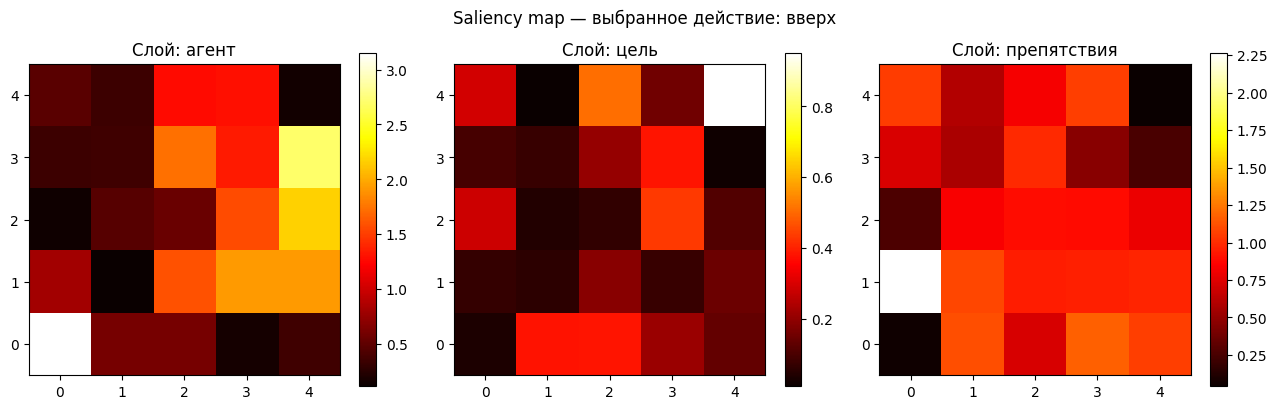

In [8]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def compute_saliency(model, obs, grid_size=5):
    """
    Считает saliency map: градиент Q-значения выбранного действия
    по каждому элементу входного наблюдения.
    """
    obs_tensor = torch.tensor(obs, dtype=torch.float32, device=model.device).unsqueeze(0)
    obs_tensor.requires_grad_(True)

    q_values = model.policy.q_net(obs_tensor)
    action = q_values.argmax(dim=1)
    selected_q = q_values[0, action]

    model.policy.q_net.zero_grad()
    selected_q.backward()

    saliency = obs_tensor.grad.data.abs().squeeze(0).cpu().numpy()

    # Наблюдение состоит из 3 слоёв по grid_size*grid_size каждый:
    # агент, цель, препятствия — разбиваем обратно
    n = grid_size * grid_size
    agent_layer = saliency[0:n].reshape(grid_size, grid_size)
    goal_layer = saliency[n:2*n].reshape(grid_size, grid_size)
    obstacle_layer = saliency[2*n:3*n].reshape(grid_size, grid_size)

    return agent_layer, goal_layer, obstacle_layer, action.item()


def plot_saliency(agent_layer, goal_layer, obstacle_layer, action):
    action_names = ['вверх', 'вниз', 'влево', 'вправо']
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    titles = ['Слой: агент', 'Слой: цель', 'Слой: препятствия']
    layers = [agent_layer, goal_layer, obstacle_layer]

    for ax, layer, title in zip(axes, layers, titles):
        im = ax.imshow(layer, cmap='hot', origin='lower')
        ax.set_title(title)
        plt.colorbar(im, ax=ax)

    fig.suptitle(f"Saliency map — выбранное действие: {action_names[action]}")
    plt.tight_layout()
    plt.show()


# Пример использования: смотрим saliency на первом шаге нового эпизода
obs, info = env.reset()
env.render()

agent_layer, goal_layer, obstacle_layer, action = compute_saliency(model, obs, grid_size=env.grid_size)
plot_saliency(agent_layer, goal_layer, obstacle_layer, action)


In [9]:
def perturbation_test(model, env, obs, agent_layer, goal_layer, obstacle_layer, original_action, grid_size=5):
    action_names = ['вверх', 'вниз', 'влево', 'вправо']

    max_idx = np.unravel_index(np.argmax(obstacle_layer), obstacle_layer.shape)
    row, col = max_idx
    print(f"Самая значимая клетка препятствия (по saliency): строка={row}, столбец={col}")
    print(f"Значимость: {obstacle_layer[row, col]:.4f}")

    n = grid_size * grid_size
    perturbed_obs = obs.copy()
    obstacle_part = perturbed_obs[2*n:3*n].reshape(grid_size, grid_size)
    obstacle_part[row, col] = 0
    perturbed_obs[2*n:3*n] = obstacle_part.flatten()

    new_action, _ = model.predict(perturbed_obs, deterministic=True)

    print(f"\nИсходное действие: {action_names[original_action]}")
    print(f"Действие после удаления препятствия: {action_names[new_action]}")

    if new_action != original_action:
        print("\n✅ Объяснение ПРАВДИВО: удаление 'важной' клетки изменило решение агента.")
    else:
        print("\n❌ Объяснение НЕ подтвердилось: решение агента не изменилось.")

    return original_action, new_action


In [17]:
original_action, new_action = perturbation_test(
    model, env, obs, agent_layer, goal_layer, obstacle_layer, action, grid_size=env.grid_size
)



Самая значимая клетка препятствия (по saliency): строка=3, столбец=1
Значимость: 1.3359

Исходное действие: вправо
Действие после удаления препятствия: вправо

❌ Объяснение НЕ подтвердилось: решение агента не изменилось.


In [10]:
import csv

n_tests = 30
confirmed = 0
results_log = []

for i in range(n_tests):
    test_obs, _ = env.reset()
    a_layer, g_layer, o_layer, act = compute_saliency(model, test_obs, grid_size=env.grid_size)
    orig_a, new_a = perturbation_test(model, env, test_obs, a_layer, g_layer, o_layer, act, grid_size=env.grid_size)
    is_confirmed = orig_a != new_a
    if is_confirmed:
        confirmed += 1
    results_log.append({
        'test_number': i,
        'original_action': int(orig_a),
        'new_action': int(new_a),
        'confirmed': is_confirmed
    })
    print("---")

success_rate = confirmed / n_tests * 100
print(f"\nИТОГО: объяснение подтвердилось в {confirmed}/{n_tests} случаях ({success_rate:.1f}%)")

# Сохраняем результаты в CSV-файл — это твои "сырые данные" для работы
with open('perturbation_results.csv', 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['test_number', 'original_action', 'new_action', 'confirmed'])
    writer.writeheader()
    writer.writerows(results_log)

print("\nРезультаты сохранены в perturbation_results.csv")


Самая значимая клетка препятствия (по saliency): строка=1, столбец=0
Значимость: 1.4768

Исходное действие: вверх
Действие после удаления препятствия: вверх

❌ Объяснение НЕ подтвердилось: решение агента не изменилось.
---
Самая значимая клетка препятствия (по saliency): строка=1, столбец=0
Значимость: 1.3136

Исходное действие: вправо
Действие после удаления препятствия: вверх

✅ Объяснение ПРАВДИВО: удаление 'важной' клетки изменило решение агента.
---
Самая значимая клетка препятствия (по saliency): строка=1, столбец=4
Значимость: 1.5612

Исходное действие: вверх
Действие после удаления препятствия: вверх

❌ Объяснение НЕ подтвердилось: решение агента не изменилось.
---
Самая значимая клетка препятствия (по saliency): строка=0, столбец=1
Значимость: 1.6215

Исходное действие: вправо
Действие после удаления препятствия: вправо

❌ Объяснение НЕ подтвердилось: решение агента не изменилось.
---
Самая значимая клетка препятствия (по saliency): строка=4, столбец=3
Значимость: 1.8985

Исхо

In [11]:
def train_agent(seed):
    train_env = GridWorldEnv(grid_size=5, n_obstacles=3)
    model = DQN(
        "MlpPolicy",
        train_env,
        learning_rate=1e-3,
        buffer_size=20000,
        learning_starts=1000,
        policy_kwargs=dict(net_arch=[128, 128]),
        verbose=0,
        seed=seed,
    )
    model.learn(total_timesteps=150000)
    model.save(f"gridworld_dqn_seed{seed}")
    return model


In [12]:
seeds = [0, 1, 2]
models = {}
for s in seeds:
    print(f"Training seed {s}...")
    models[s] = train_agent(s)
print("Готово, все 3 агента обучены")


Training seed 0...
Training seed 1...
Training seed 2...
Готово, все 3 агента обучены


In [13]:
import random
def run_faithfulness_experiment(model, n_trials, seed_label):
    exp_env = GridWorldEnv(grid_size=5, n_obstacles=3)
    records = []
    for trial in range(n_trials):
        obs, info = exp_env.reset()

        _result = compute_saliency(model, obs)
        obstacle_saliency_layer = np.asarray(_result[2], dtype=float)  # 3-й элемент = obstacle-слой
        original_action = int(_result[3])                              # 4-й элемент = action

        # q_margin считаем отдельно напрямую через модель
        obs_tensor = torch.tensor(obs, dtype=torch.float32, device=model.device).unsqueeze(0)
        with torch.no_grad():
            q_values_tensor = model.policy.q_net(obs_tensor)
        q_vals = q_values_tensor.cpu().numpy().flatten()
        q_sorted = np.sort(q_vals)[::-1]
        q_margin = float(q_sorted[0] - q_sorted[1])

        obstacles = exp_env.obstacles
        sal_values = [float(obstacle_saliency_layer[o[1], o[0]]) for o in obstacles]

        actions_after_removal = []
        for o in obstacles:
            modified_obs = remove_obstacle(obs, o, exp_env.grid_size)
            new_action, _states = model.predict(modified_obs, deterministic=True)
            actions_after_removal.append(int(new_action))
        changed = [a != original_action for a in actions_after_removal]

        top_idx = int(np.argmax(sal_values))
        least_idx = int(np.argmin(sal_values))
        random_idx = random.randrange(len(obstacles))

        records.append({
            "seed": seed_label,
            "trial": trial,
            "original_action": original_action,
            "q_margin": q_margin,
            "saliency_values": sal_values,
            "changed": changed,
            "faithful_top_salient": changed[top_idx],
            "faithful_least_salient": changed[least_idx],
            "faithful_random": changed[random_idx],
        })
    return records



In [14]:
obs, info = GridWorldEnv(grid_size=5, n_obstacles=3).reset()
test_result = compute_saliency(models[0], obs)
env_check = GridWorldEnv(grid_size=5, n_obstacles=3)
env_check.reset()
print("Настоящие препятствия:", env_check.obstacles)
for i in range(3):
    layer = np.asarray(test_result[i])
    print(f"Слой {i}, максимум в точках препятствий:",
          [round(float(layer[o[1], o[0]]), 3) for o in env_check.obstacles],
          "| общий максимум слоя:", round(float(layer.max()), 3))


Настоящие препятствия: [array([4, 0]), array([1, 3]), array([0, 2])]
Слой 0, максимум в точках препятствий: [0.955, 1.0, 0.268] | общий максимум слоя: 2.442
Слой 1, максимум в точках препятствий: [0.126, 0.101, 0.081] | общий максимум слоя: 1.994
Слой 2, максимум в точках препятствий: [0.91, 0.902, 0.823] | общий максимум слоя: 1.189


In [15]:
obs, info = GridWorldEnv(grid_size=5, n_obstacles=3).reset()
test_result = compute_saliency(models[0], obs)
print("Количество возвращаемых значений:", len(test_result))
for i, x in enumerate(test_result):
    print(i, type(x), np.shape(x) if hasattr(x, 'shape') else 'не массив/скаляр:', x if not hasattr(x, 'shape') else '')


Количество возвращаемых значений: 4
0 <class 'numpy.ndarray'> (5, 5) 
1 <class 'numpy.ndarray'> (5, 5) 
2 <class 'numpy.ndarray'> (5, 5) 
3 <class 'int'> не массив/скаляр: 0


In [16]:
all_records = []
for s in seeds:
    print(f"Running experiment for seed {s}...")
    all_records.extend(run_faithfulness_experiment(models[s], n_trials=100, seed_label=s))

df_multi = pd.DataFrame(all_records)
df_multi.to_csv("faithfulness_multiseed.csv", index=False)
print("Сохранено:", len(df_multi), "строк")
print(df_multi.groupby("seed")[["faithful_top_salient","faithful_least_salient","faithful_random"]].mean())


Running experiment for seed 0...
Running experiment for seed 1...
Running experiment for seed 2...
Сохранено: 300 строк
      faithful_top_salient  faithful_least_salient  faithful_random
seed                                                               
0                     0.44                    0.27             0.31
1                     0.30                    0.23             0.25
2                     0.23                    0.08             0.15


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
